In [73]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import polars as pl
import polars.selectors as cs
import numpy as np
from pathlib import Path
from catboost import CatBoostRanker, Pool

SEED = 42
TOPK = 10
DATA_DIR = Path("./data")
GROUP_COL, ITEM_COL, LABEL_COL = "x", "item_id", "strong_target"
FLOAT_COLS = [f"float_{i}" for i in range(1, 81)]
CAT_COLS = ["cat_1", "cat_2", "cat_3"]

In [74]:
def load_split(path):
    df = pl.read_parquet(path)
    return df.with_columns(cs.numeric().fill_nan(cs.numeric().median())).with_columns(cs.numeric().fill_null(cs.numeric().median()))


train = load_split(DATA_DIR / "train/train.parquet")
val = load_split(DATA_DIR / "val/val.parquet")
test = load_split(DATA_DIR / "test/test.parquet")

print("train:", train.shape, "  val:", val.shape)
print("train groups:", train[GROUP_COL].n_unique(), " val groups:", val[GROUP_COL].n_unique())
print("train positives:", (train[LABEL_COL] >= 1).sum(), " val positives:", (val[LABEL_COL] >= 1).sum())

train: (2795348, 89)   val: (73947, 89)
train groups: 48617  val groups: 1345
train positives: 72314  val positives: 1905


In [75]:
items = pl.read_parquet("data/item_embeddings.parquet")

item_to_idx = {items["item_id"][iid]: iid  for iid in range(len(items["item_id"]))}
items_embs = items['embedding'].to_numpy()
def get_emb(item_id):
    idx = item_to_idx.get(int(item_id))
    if idx is not None:  
        return items_embs[idx]
    else:
        raise ValueError(f"no embedding for item_id {item_id}")


print(f"Embedding table: {len(item_to_idx):,} items  dim={len(items_embs[0])}")

Embedding table: 2,903,192 items  dim=768


In [ ]:
def build_samples(df):
    rows = []
    for (x,), grp in df.group_by([GROUP_COL], maintain_order=True):
        item_ids  = grp[ITEM_COL].to_numpy()
        labels    = (grp[LABEL_COL].to_numpy() >= 1).astype(np.int32)
        float_mat = grp.select(FLOAT_COLS).to_numpy().astype(np.float32)
        cat_mat   = grp.select(CAT_COLS).to_numpy()  # (n, 3) — original cats only
        embs = items_embs[[item_to_idx.get(int(i), 0) for i in item_ids]]
        n = len(item_ids)
        for k in np.where(labels)[0]:
            if k + 1 >= n or labels[k + 1:].sum() == 0:
                continue
            liked_emb = embs[k]
            sims = embs[k + 1:] @ liked_emb
            query_id = f"{x}_{k}"
            liked_cat_strs = [str(cat_mat[k, ci]) for ci in range(3)]
            for j, pos in enumerate(range(k + 1, n)):
                cand_cat_strs = [str(cat_mat[pos, ci]) for ci in range(3)]
                row = {
                    "query_id":      query_id,
                    "sim_to_liked":  float(sims[j]),
                    "label":         int(labels[pos]),
                    "original_rank": j + 1,
                    "cat_1_match":   int(cand_cat_strs[0] == liked_cat_strs[0]),
                    "cat_2_match":   int(cand_cat_strs[1] == liked_cat_strs[1]),
                    "cat_3_match":   int(cand_cat_strs[2] == liked_cat_strs[2]),
                    "liked_cat_1":   liked_cat_strs[0],
                    "liked_cat_2":   liked_cat_strs[1],
                    "liked_cat_3":   liked_cat_strs[2],
                }
                for fi, fc in enumerate(FLOAT_COLS):
                    row[fc] = float(float_mat[pos, fi])
                for ci, cc in enumerate(CAT_COLS):
                    row[cc] = cand_cat_strs[ci]
                rows.append(row)
    return pl.DataFrame(rows)


print("Building train samples...")
train_samples = build_samples(train)
print("Building val samples...")
val_samples = build_samples(val)
print("Building test samples...")
test_samples = build_samples(test)
print(f"Train: {train_samples['query_id'].n_unique():,} queries, {len(train_samples):,} rows")
print(f"Val:   {val_samples['query_id'].n_unique():,} queries, {len(val_samples):,} rows")
print(f"Test:   {test_samples['query_id'].n_unique():,} queries, {len(test_samples):,} rows")

Building train samples...


Building val samples...
Train: 23,697 queries, 1,042,089 rows
Val:   560 queries, 23,178 rows
Val positive rate: 0.048


In [77]:
LIKED_CAT_COLS = ["liked_cat_1", "liked_cat_2", "liked_cat_3"]
MATCH_COLS = ["cat_1_match", "cat_2_match", "cat_3_match"]

CAT_COLS = CAT_COLS + LIKED_CAT_COLS
NUM_COLS = ["sim_to_liked"] + FLOAT_COLS + MATCH_COLS
FEATURE_COLS = NUM_COLS + CAT_COLS

In [78]:
def rerank_metrics(samples, score_col, k=TOPK):
    """
    Для каждого query_id: сортировка по score_col desc → NDCG@K.
    rank_lift = original_rank - reranked_rank для позитивов (> 0 = поднялся).
    """
    ndcgs, lifts, lift_rates = [], [], []
    for (qid,), grp in samples.group_by(["query_id"], maintain_order=True):
        sorted_grp = grp.sort(score_col, descending=True)
        lbl = sorted_grp["label"].to_numpy()
        top = lbl[:k]
        gains = top / np.log2(np.arange(2, 2 + len(top)))
        ideal_lbl = np.sort(grp["label"].to_numpy())[::-1][:k]
        ideal = ideal_lbl / np.log2(np.arange(2, 2 + len(ideal_lbl)))
        idcg = ideal.sum()
        ndcgs.append(gains.sum() / idcg if idcg > 0 else 0.0)

        pos_orig = grp.filter(pl.col("label") == 1)["original_rank"].to_numpy()
        if len(pos_orig):
            pos_reranked = sorted_grp.with_row_index("rr").filter(pl.col("label") == 1)["rr"].to_numpy() + 1
            diff = pos_orig - pos_reranked
            lifts.append(float(diff.mean()))
            lift_rates.append(float((diff > 0).mean()))

    return {
        f"NDCG@{k}": float(np.mean(ndcgs)),
        "mean_rank_lift": float(np.mean(lifts)) if lifts else 0.0,
        "pct_lifted": float(np.mean(lift_rates)) if lift_rates else 0.0,
        "n_queries": len(ndcgs),
    }

In [79]:
val_orig = val_samples.with_columns((-pl.col("original_rank")).alias("orig_score"))

m_orig = rerank_metrics(val_orig, "orig_score")
m_sim = rerank_metrics(val_samples, "sim_to_liked")

print(
    f"{'Original order':35s}  NDCG@{TOPK}={m_orig[f'NDCG@{TOPK}']:.4f}  "
    f"rank_lift={m_orig['mean_rank_lift']:+.2f}  pct_lifted={m_orig['pct_lifted']:.1%}"
)
print(
    f"{'Similarity':35s}  NDCG@{TOPK}={m_sim[f'NDCG@{TOPK}']:.4f}  "
    f"rank_lift={m_sim['mean_rank_lift']:+.2f}  pct_lifted={m_sim['pct_lifted']:.1%}"
)

Original order                       NDCG@10=0.1985  rank_lift=+0.00  pct_lifted=0.0%
Similarity                           NDCG@10=0.3036  rank_lift=+7.34  pct_lifted=62.8%


In [80]:
cat_feat_idx = [FEATURE_COLS.index(c) for c in CAT_COLS]

def make_pool(df):
    df = df.sort("query_id")
    num  = df.select(NUM_COLS).to_numpy()
    cats = df.select(CAT_COLS).to_numpy().astype(object)
    X = np.empty((len(df), len(FEATURE_COLS)), dtype=object)
    X[:, :len(NUM_COLS)] = num
    X[:, len(NUM_COLS):] = cats
    return Pool(
        X,
        label=df["label"].to_numpy(),
        group_id=df["query_id"].to_numpy(),
        cat_features=cat_feat_idx,
    )

train_pool = make_pool(train_samples)
val_pool   = make_pool(val_samples)


In [81]:
cb = CatBoostRanker(
    loss_function="YetiRank",
    eval_metric="NDCG:top=10",
    iterations=300,
    early_stopping_rounds=50,
    depth=5,
    random_seed=SEED,
    verbose=25,
    one_hot_max_size=52,
)
cb.fit(train_pool, eval_set=val_pool)


0:	test: 0.1874233	best: 0.1874233 (0)	total: 646ms	remaining: 3m 13s
25:	test: 0.3253622	best: 0.3253622 (25)	total: 6.26s	remaining: 1m 5s
50:	test: 0.3359699	best: 0.3361794 (45)	total: 12.1s	remaining: 59.2s
75:	test: 0.3433662	best: 0.3433662 (75)	total: 18s	remaining: 53.1s
100:	test: 0.3420950	best: 0.3443597 (76)	total: 23.7s	remaining: 46.6s
125:	test: 0.3379198	best: 0.3443597 (76)	total: 29.7s	remaining: 41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.3443596585
bestIteration = 76

Shrink model to first 77 iterations.


CatBoostRanker(depth=5, early_stopping_rounds=50, eval_metric='NDCG:top=10', iterations=300, loss_function='YetiRank', one_hot_max_size=52, random_seed=42, verbose=25)

In [82]:
cb_scores = cb.predict(val_pool)
val_with_cb = val_samples.sort("query_id").with_columns(pl.Series("cb_score", cb_scores))
m_cb = rerank_metrics(val_with_cb, "cb_score")

results = [
    ("Original order", m_orig),
    ("Similarity", m_sim),
    ("CatBoost", m_cb),
]
print(f"{'Method':35s}  {f'NDCG@{TOPK}':10s}  {'rank_lift':10s}  pct_lifted")
print("-" * 75)
for name, m in results:
    print(f"{name:35s}  {m[f'NDCG@{TOPK}']:.4f}      {m['mean_rank_lift']:+.2f}        {m['pct_lifted']:.1%}")

Method                               NDCG@10     rank_lift   pct_lifted
---------------------------------------------------------------------------
Original order                       0.1985      +0.00        0.0%
Similarity                           0.3036      +7.34        62.8%
CatBoost                             0.3444      +10.01        70.3%


In [83]:
os.makedirs("data/models", exist_ok=True)
cb.save_model("data/models/reranker_catboost.cbm")
print("Model saved → data/models/reranker_catboost.cbm")

Model saved → data/models/reranker_catboost.cbm


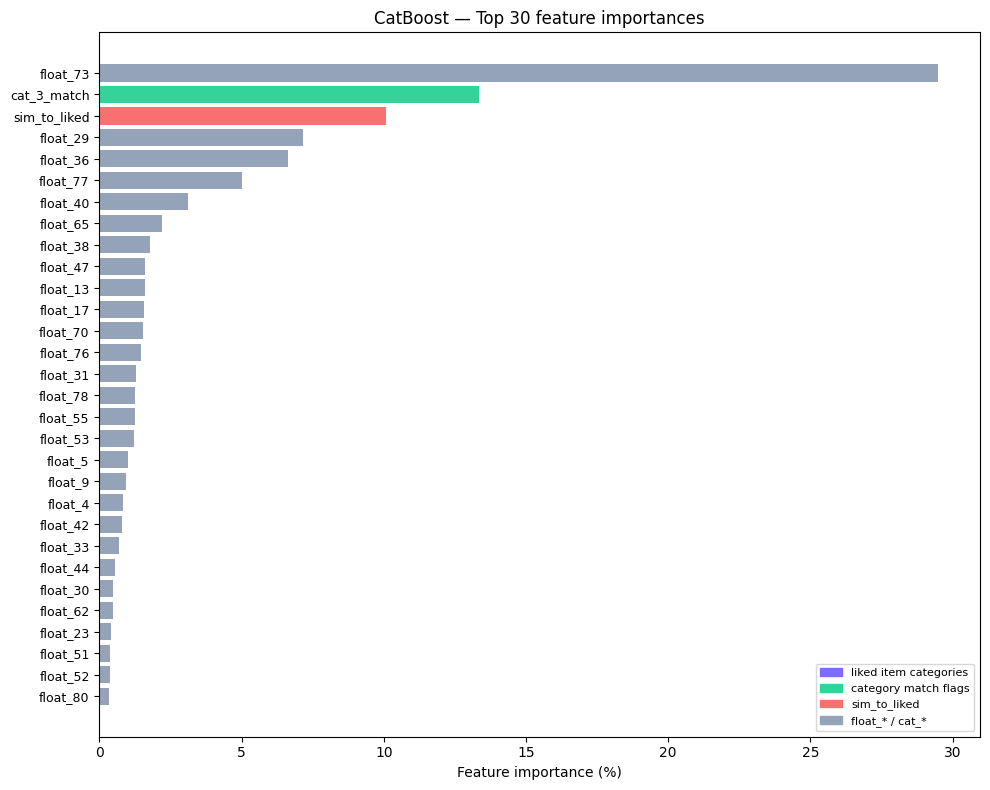


Top-10 features:
  float_73              29.49%
  cat_3_match           13.35%
  sim_to_liked          10.08%
  float_29              7.17%
  float_36              6.63%
  float_77              5.02%
  float_40              3.13%
  float_65              2.20%
  float_38              1.77%
  float_47              1.62%


In [84]:
importances = cb.get_feature_importance(type="PredictionValuesChange")
fi = sorted(zip(FEATURE_COLS, importances), key=lambda x: x[1], reverse=True)
names, vals = zip(*fi)

TOP = 30
names, vals = names[:TOP], vals[:TOP]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(TOP), vals[::-1], color=[
    "#7c6dfa" if n.startswith("liked_cat") else
    "#34d399" if n.endswith("_match") else
    "#f87171" if n == "sim_to_liked" else
    "#94a3b8"
    for n in names[::-1]
])
ax.set_yticks(range(TOP))
ax.set_yticklabels(names[::-1], fontsize=9)
ax.set_xlabel("Feature importance (%)")
ax.set_title(f"CatBoost — Top {TOP} feature importances")
legend = [
    Patch(color="#7c6dfa", label="liked item categories"),
    Patch(color="#34d399", label="category match flags"),
    Patch(color="#f87171", label="sim_to_liked"),
    Patch(color="#94a3b8", label="float_* / cat_*"),
]
ax.legend(handles=legend, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

print("\nTop-10 features:")
for name, val in fi[:10]:
    print(f"  {name:20s}  {val:.2f}%")
